# view_gen3.ipynb - 3代RNA测序数据可视化 / 3rd-Generation RNA Sequencing Data Visualization

可视化 3 代 (PacBio/ONT) RNA 测序数据:12 类修饰位点分布、序列特征、统计图表。
Visualizes 3rd-generation (PacBio/ONT) RNA sequencing data: 12-class modification site distribution, sequence features, statistical plots.

## 功能模块 / Modules
- 数据加载 (3gen npy) / Data loading (3gen npy)
- 12 类修饰位点分布 / 12-class modification site distribution
- 序列特征分析 / Sequence feature analysis
- 统计图表生成 / Statistical plot generation

## 输入 / Inputs
- 3gen/seq.npy: NumPy 字节数组 (N, 1001) |S1 - 3代 RNA 序列 / 3gen RNA sequences
- 3gen/1001loc.npy: NumPy int8 (N, 1001) - 1001 位点级标签 / 1001 site-level labels
- 3gen/12loc.npy: NumPy int8 (N, 12) - 12 类多热标签 / 12-class multi-hot labels

## 输出 / Outputs
- 内嵌图表 / Inline plots (matplotlib)
- 表格 / Tables (pandas)
- 可选保存到 fig/ / Optional save to fig/

## 数据流 / Data Flow
1. 加载 3gen 数据 / Load 3gen data
2. 统计每类位点数 / Count sites per class per sequence
3. 绘制分布 / Plot distributions
4. 显示 + 保存 / Display + save

## 相关文件 / Related Files
- 调用 / Calls: dataset.gen3.Gen3Dataset, matplotlib, seaborn
- 被调用 / Called by: manual execution in Jupyter

## 使用示例 / Usage Example
    在 Jupyter 中打开并按顺序执行所有 cells / Open in Jupyter and run all cells sequentially

## 作者 / Author: RGCNFormer Project
## 日期 / Date: 2026-06-03
## 版本 / Version: 1.0

# 3gen 数据可视化分析

这个 notebook 用于探索分析 3gen 测序RNA修饰数据集，包括：
- 数据基本统计信息
- 修饰分布统计
- 数据分布可视化


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline

plt.style.use('seaborn-v0_8')
sns.set(font_scale=1.2)

# 标签映射 (来自 dataset/gen3.py)
LABEL_MAPPING = {
    1: 0,   # Am
    2: 1,   # Atol
    3: 2,   # Cm
    4: 3,   # Gm
    5: 4,   # Tm
    6: 5,   # Y
    7: 6,   # ac4C
    8: 7,   # m1A
    9: 8,   # m5C
    10: 9,  # m6A
    11: 10, # m6Am
    12: 11  # m7G
}

MOD_NAMES = {
    0: 'Am',     1: 'Atol',   2: 'Cm',
    3: 'Gm',     4: 'Tm',     5: 'Y',
    6: 'ac4C',   7: 'm1A',    8: 'm5C',
    9: 'm6A',    10: 'm6Am',  11: 'm7G'
}

INDEX_TO_NUCLEOTIDE = {
    0: 'A', 1: 'A',
    2: 'C',
    3: 'G',
    4: 'U', 5: 'U',
    6: 'C',
    7: 'A',
    8: 'C',
    9: 'A', 10: 'A',
    11: 'G'
}

## 1. 加载数据并查看基本信息

In [2]:
# 加载数据
data_dir = 'npy/3gen_alignment'

sequences = np.load(f'{data_dir}/seq.npy', mmap_mode='r')
full_labels = np.load(f'{data_dir}/1001loc.npy', mmap_mode='r')
y_12class = np.load(f'{data_dir}/12loc.npy', mmap_mode='r')
y_4class = np.load(f'{data_dir}/4loc.npy', mmap_mode='r')

print(f"数据目录: {data_dir}")
print(f"序列数量: {len(sequences)}")
print(f"序列形状: {sequences.shape}")
print(f"full_labels (1001loc) 形状: {full_labels.shape}")
print(f"y_12class (12loc) 形状: {y_12class.shape}")
print(f"y_4class (4loc) 形状: {y_4class.shape}")
print(f"序列dtype: {sequences.dtype}")
print(f"labels dtype: {full_labels.dtype}")

数据目录: npy/3gen_alignment
序列数量: 4546
序列形状: (4546,)
full_labels (1001loc) 形状: (4546, 1001)
y_12class (12loc) 形状: (4546, 12)
y_4class (4loc) 形状: (4546, 4)
序列dtype: |S1001
labels dtype: int8


## 2. 修饰位点统计分析

统计每种修饰共有多少个位点

In [3]:
# 统计每种修饰的位点数
mod_counts = {i: 0 for i in range(1, 13)}

for seq_idx in range(len(full_labels)):
    labels = full_labels[seq_idx]
    for pos in range(1001):
        label = labels[pos]
        if label != 0:
            mod_counts[label] += 1

# 转换为DataFrame
counts_data = []
for mod_id, count in mod_counts.items():
    model_idx = LABEL_MAPPING[mod_id]
    mod_name = MOD_NAMES[model_idx]
    nucleotide = INDEX_TO_NUCLEOTIDE[model_idx]
    counts_data.append({
        'mod_id': mod_id,
        'mod_name': mod_name,
        'nucleotide': nucleotide,
        'site_count': count
    })

counts_df = pd.DataFrame(counts_data)
counts_df = counts_df.sort_values('site_count', ascending=False)
counts_df = counts_df.reset_index(drop=True)
counts_df.index = counts_df.index + 1

print("每种修饰的位点数统计:")
display(counts_df)
print(f"\n总修饰位点数: {counts_df['site_count'].sum()}")
print(f"平均每条序列修饰位点数: {counts_df['site_count'].sum() / len(full_labels):.2f}")

每种修饰的位点数统计:


,mod_id,mod_name,nucleotide,site_count
1,10,m6A,A,17863
2,1,Am,A,0
3,3,Cm,C,0
4,2,Atol,A,0
5,4,Gm,G,0
6,5,Tm,U,0
7,7,ac4C,C,0
8,6,Y,U,0
9,8,m1A,A,0
10,9,m5C,C,0



总修饰位点数: 17863
平均每条序列修饰位点数: 3.93


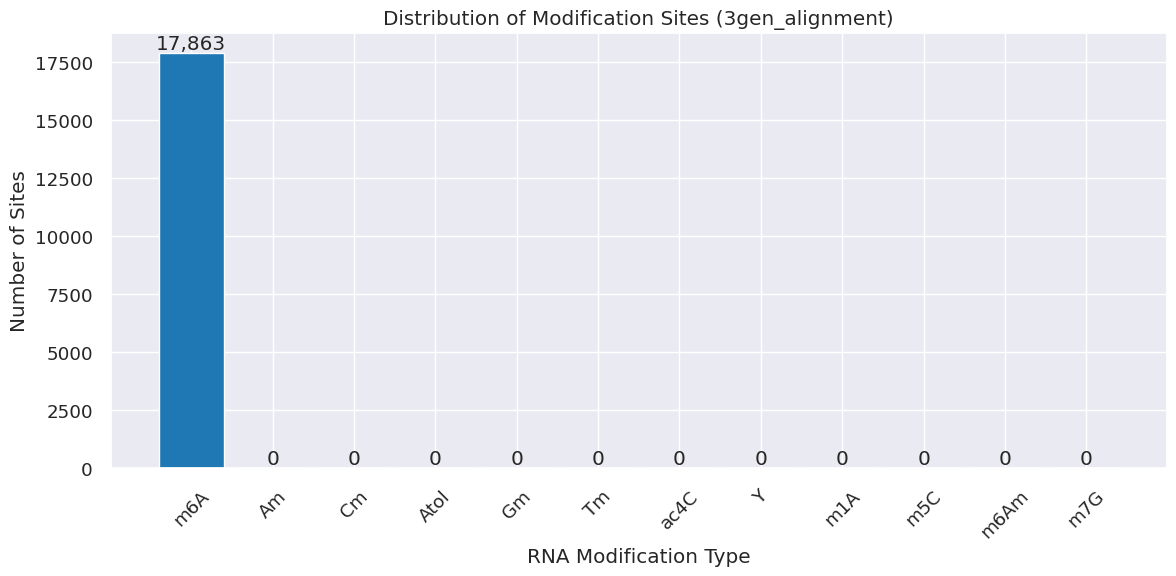

In [4]:
# 可视化修饰位点分布
plt.figure(figsize=(12, 6))
mod_names = counts_df['mod_name']
site_counts = counts_df['site_count']

colors = ['#1f77b4' if cnt == site_counts.max() else '#8c8c8c' for cnt in site_counts]
bars = plt.bar(mod_names, site_counts, color=colors)

plt.xlabel('RNA Modification Type')
plt.ylabel('Number of Sites')
plt.title('Distribution of Modification Sites (3gen_alignment)')
plt.xticks(rotation=45)

# 在柱状图上添加数值标签
for bar, cnt in zip(bars, site_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{cnt:,}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('output/violin_mod_counts.png', dpi=300, bbox_inches='tight')
plt.savefig('output/violin_mod_counts.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 3. 每条序列修饰数量分布

统计每条序列包含多少个修饰位点

In [5]:
# 计算每条序列的修饰位点数
mods_per_sequence = []

for seq_idx in range(len(full_labels)):
    labels = full_labels[seq_idx]
    count = np.sum(labels != 0)
    mods_per_sequence.append(count)

mods_per_sequence = np.array(mods_per_sequence)

print(f"每条序列修饰位点数量统计:")
print(f"  最小值: {mods_per_sequence.min()}")
print(f"  最大值: {mods_per_sequence.max()}")
print(f"  平均值: {mods_per_sequence.mean():.2f}")
print(f"  中位数: {np.median(mods_per_sequence):.2f}")
print(f"  标准差: {mods_per_sequence.std():.2f}")

每条序列修饰位点数量统计:
  最小值: 1
  最大值: 18
  平均值: 3.93
  中位数: 3.00
  标准差: 2.89


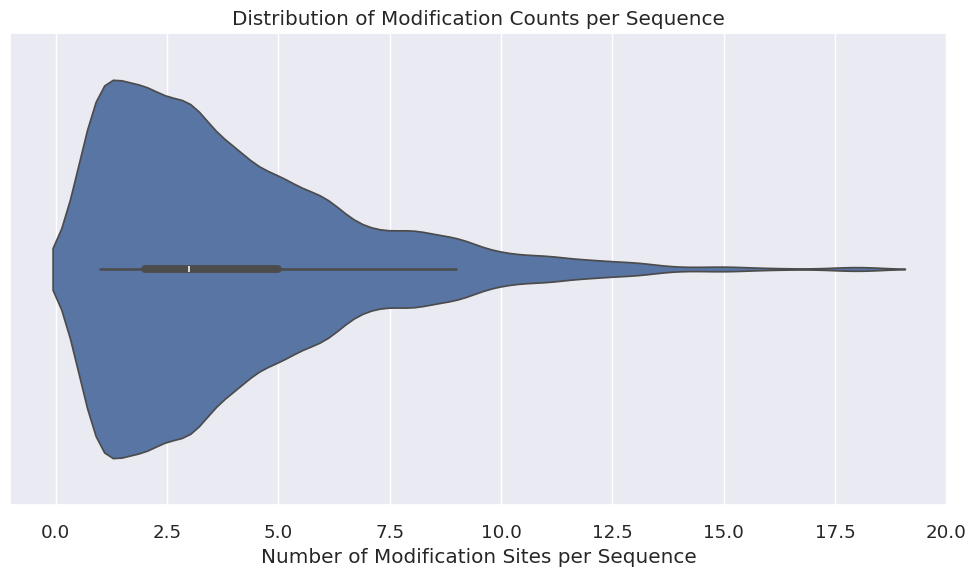

In [6]:
# 小提琴图展示修饰数量分布
plt.figure(figsize=(10, 6))
sns.violinplot(data=mods_per_sequence, orient='h')
plt.xlabel('Number of Modification Sites per Sequence')
plt.title('Distribution of Modification Counts per Sequence')
plt.tight_layout()
plt.savefig('output/violin_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 4. 12类多标签分布分析

查看每条序列有多少种不同的修饰类型

In [7]:
# 统计每条序列有多少种修饰类型
classes_per_sequence = []

for seq_idx in range(len(y_12class)):
    labels = y_12class[seq_idx]
    count = np.sum(labels == 1)
    classes_per_sequence.append(count)

classes_per_sequence = np.array(classes_per_sequence)

print(f"每条序列修饰类型数量统计:")
print(f"  最小值: {classes_per_sequence.min()}")
print(f"  最大值: {classes_per_sequence.max()}")
print(f"  平均值: {classes_per_sequence.mean():.2f}")
print(f"  中位数: {np.median(classes_per_sequence):.2f}")

每条序列修饰类型数量统计:
  最小值: 1
  最大值: 1
  平均值: 1.00
  中位数: 1.00


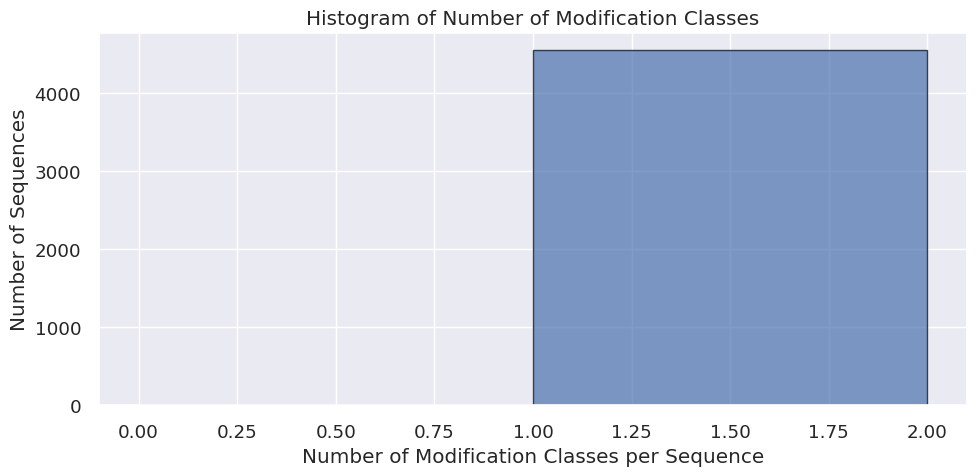

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(classes_per_sequence, bins=np.arange(0, classes_per_sequence.max()+2), 
         alpha=0.7, edgecolor='black')
plt.xlabel('Number of Modification Classes per Sequence')
plt.ylabel('Number of Sequences')
plt.title('Histogram of Number of Modification Classes')
plt.tight_layout()
plt.show()

## 5. 4类核苷酸组分布

A: 4546 sequences
C: 0 sequences
G: 0 sequences
U: 0 sequences


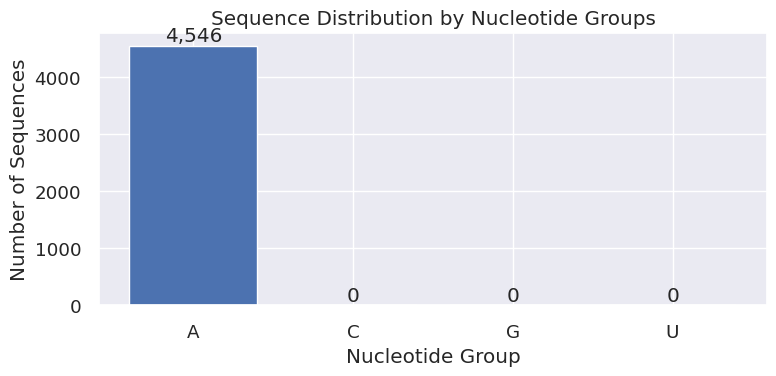

In [9]:
# 4类统计
nuc_names = ['A', 'C', 'G', 'U']
nuc_counts = []

for i in range(4):
    count = np.sum(y_4class[:, i] == 1)
    nuc_counts.append(count)
    print(f"{nuc_names[i]}: {count} sequences")

plt.figure(figsize=(8, 4))
plt.bar(nuc_names, nuc_counts)
plt.xlabel('Nucleotide Group')
plt.ylabel('Number of Sequences')
plt.title('Sequence Distribution by Nucleotide Groups')
for i, v in enumerate(nuc_counts):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 总结

- 总序列数: **{len(full_labels)}**
- 总修饰位点数: **{counts_df['site_count'].sum()}**
- 平均每条序列修饰位点数: **{counts_df['site_count'].sum() / len(full_labels):.2f}**

In [10]:
# 从这里可以复制去别的地方用
print(f"序列数: {len(full_labels)}")
print(f"总修饰位点数: {counts_df['site_count'].sum()}")
for idx, row in counts_df.iterrows():
    print(f"  {row['mod_name']}: {row['site_count']}")

序列数: 4546
总修饰位点数: 17863
  m6A: 17863
  Am: 0
  Cm: 0
  Atol: 0
  Gm: 0
  Tm: 0
  ac4C: 0
  Y: 0
  m1A: 0
  m5C: 0
  m6Am: 0
  m7G: 0
